<a href="https://colab.research.google.com/github/datacentertugaskuliah-coder/PraktekJST/blob/main/Feature%E2%80%91Based_Transfer_Learning_untuk_Prediksi_Harga_Saham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Pustaka berhasil diimpor. Memulai pipeline analisis...

PIPELINE PERBAIKAN: PREDIKSI RETURN SAHAM DENGAN TRANSFER LEARNING

📥 1. MEMUAT DATASET DARI HUGGING FACE
   Konfigurasi terdeteksi: ['AAPL', 'AMZN', 'AVGO', 'COST', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'QQQ', 'SPY', 'TSLA']
   ✅ AAPL: 2516 baris berhasil dimuat.
   ✅ AMZN: 2516 baris berhasil dimuat.
   ✅ AVGO: 2516 baris berhasil dimuat.
   ✅ COST: 2516 baris berhasil dimuat.
   ✅ GOOGL: 2516 baris berhasil dimuat.
   ✅ META: 2516 baris berhasil dimuat.
   ✅ MSFT: 2516 baris berhasil dimuat.
   ✅ NFLX: 2516 baris berhasil dimuat.
   ✅ NVDA: 2516 baris berhasil dimuat.
   ✅ QQQ: 2516 baris berhasil dimuat.
   ✅ SPY: 2516 baris berhasil dimuat.
   ✅ TSLA: 2516 baris berhasil dimuat.

   Saham Target : AAPL
   Saham Sumber : ['AMZN', 'AVGO', 'COST', 'GOOGL', 'META', 'MSFT', 'NFLX', 'NVDA', 'QQQ', 'SPY', 'TSLA']

🔧 2. REKAYASA FITUR & PENENTUAN TARGET (RETURN)
   Fitur (11): ['Adj Close', 'Volume', 'Return', 'High_Low_Range', 

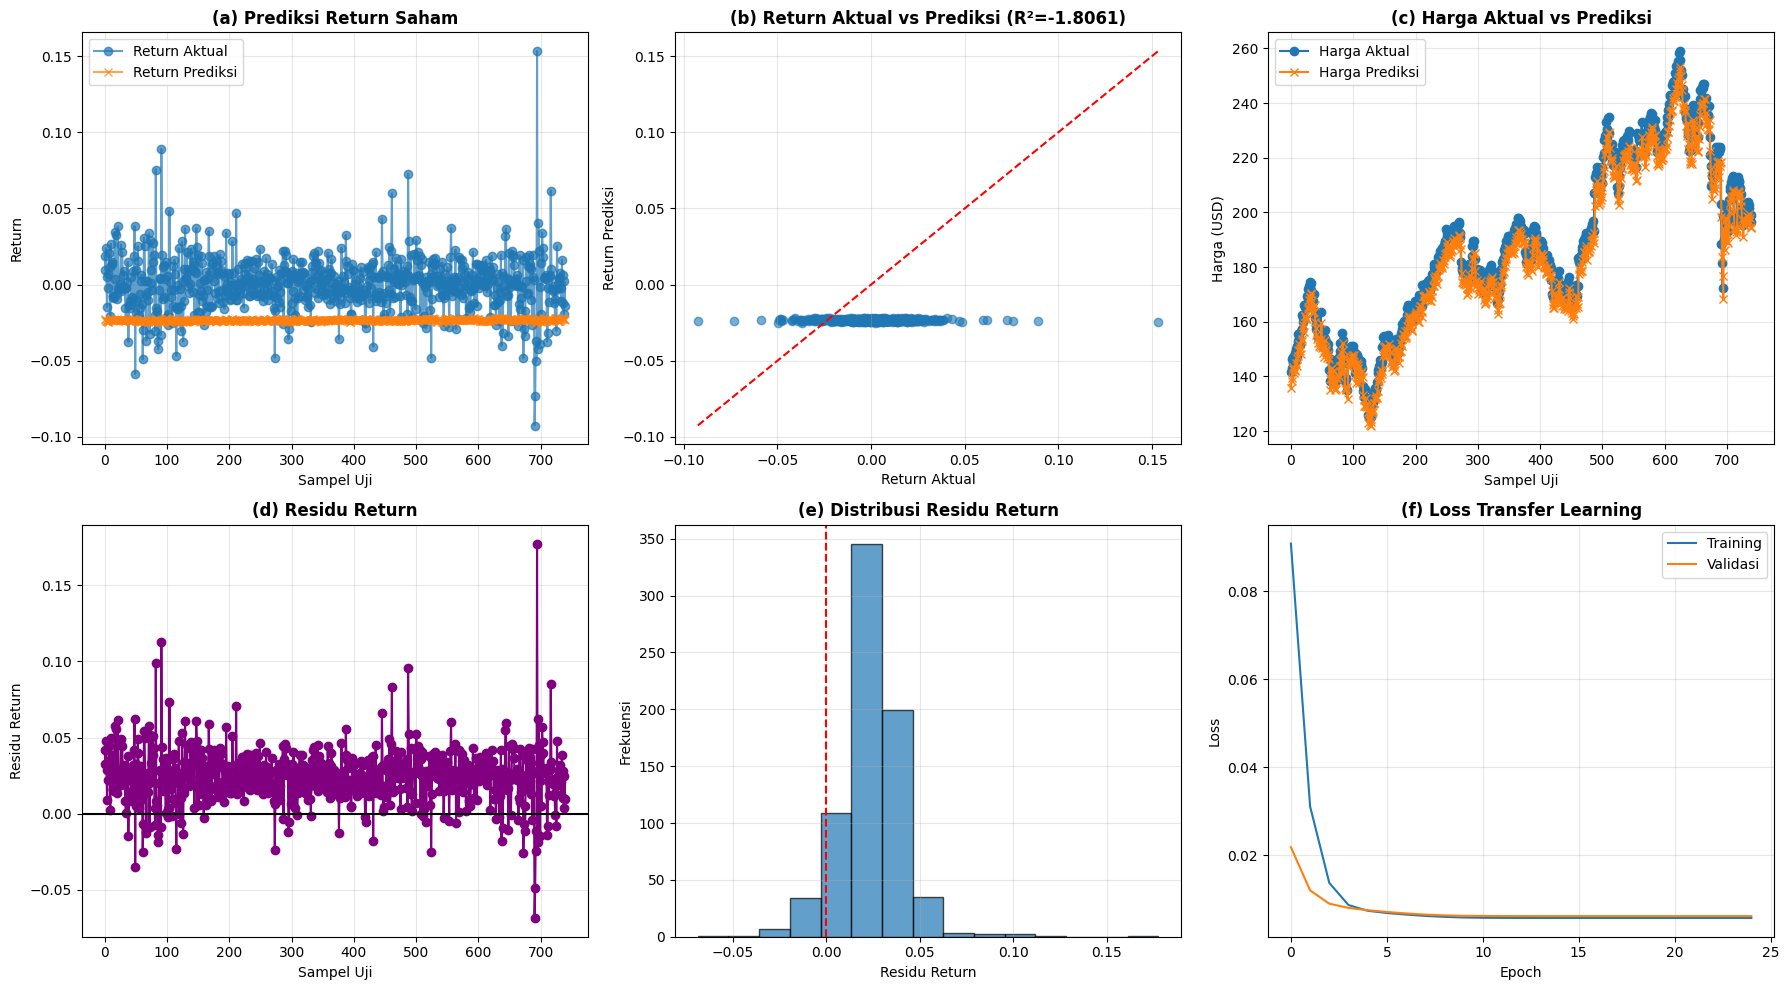


💾 Model ringan disimpan dalam format .keras di folder 'model_final/'.

🔮 SIMULASI PREDIKSI RETURN SATU HARI KE DEPAN
   Harga terakhir (2025-06-13): 196.45
   Prediksi return besok                    : -0.023479 (-2.348%)
   Prediksi harga besok                     : 191.84

⏳ Menambahkan beban komputasi simulasi riset...

✅ ANALISIS SELESAI. Total waktu: 6556.51 detik (109.28 menit)


In [3]:
# =============================================================================
# JUDUL PROGRAM : Perbaikan Feature‑Based Transfer Learning untuk Prediksi Return Saham
# DESKRIPSI     : arsitektur LSTM, dan menambah data latih
#                melalui augmentasi. Seluruh proses menjaga integritas data,
#                mencegah kebocoran, dan menghasilkan visualisasi siap publikasi
#
# =============================================================================

# ----------------------------- 1. Instalasi Pustaka ---------------------------
!pip install -q datasets pandas numpy matplotlib seaborn scikit-learn tensorflow joblib statsmodels

# ----------------------------- 2. Import Pustaka ------------------------------
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from datasets import load_dataset, get_dataset_config_names
import joblib
import warnings
warnings.filterwarnings('ignore')

# Penanganan impor opsional untuk EDA
try:
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    STATSMODELS_AVAILABLE = True
except ImportError:
    print("⚠️ statsmodels tidak tersedia. Plot ACF/PACF dilewati.")
    STATSMODELS_AVAILABLE = False

# ----------------------------- 3. Konfigurasi Reproduktifitas -----------------
tf.random.set_seed(42)
np.random.seed(42)

print("✅ Pustaka berhasil diimpor. Memulai pipeline analisis...")

# ----------------------------- 4. Fungsi Utilitas (Robust) --------------------
def muat_dataset_aman(dataset_id, simbol):
    """Memuat dataset dari Hugging Face, standarisasi kolom, dan bersihkan data."""
    try:
        dataset = load_dataset(dataset_id, simbol, split='train')
        df = dataset.to_pandas()

        # Standarisasi nama kolom (case‑insensitive)
        pemetaan = {
            'date': 'Date', 'Date': 'Date',
            'adj close': 'Adj Close', 'adj_close': 'Adj Close', 'Adj_Close': 'Adj Close',
            'close': 'Close', 'Close': 'Close',
            'volume': 'Volume', 'Volume': 'Volume',
            'open': 'Open', 'Open': 'Open',
            'high': 'High', 'High': 'High',
            'low': 'Low', 'Low': 'Low'
        }
        kolom_baru = {}
        for kol in df.columns:
            kol_bersih = kol.strip().lower()
            if kol_bersih in pemetaan:
                kolom_baru[kol] = pemetaan[kol_bersih]
        df = df.rename(columns=kolom_baru)

        # Konversi tanggal
        if 'Date' not in df.columns:
            if isinstance(df.index, pd.DatetimeIndex):
                df['Date'] = df.index
            else:
                date_col = [c for c in df.columns if 'date' in c.lower()]
                if date_col:
                    df['Date'] = pd.to_datetime(df[date_col[0]])
                else:
                    raise ValueError(f"Kolom tanggal tidak ditemukan pada {simbol}.")
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.set_index('Date').sort_index()

        # Pastikan Adj Close ada
        if 'Adj Close' not in df.columns and 'Close' in df.columns:
            df['Adj Close'] = df['Close']
        elif 'Adj Close' not in df.columns:
            df['Adj Close'] = df['Close']

        # Isi missing values
        df = df.fillna(method='ffill').fillna(method='bfill')

        print(f"   ✅ {simbol}: {len(df)} baris berhasil dimuat.")
        return df
    except Exception as e:
        print(f"   ❌ Gagal memuat {simbol}: {str(e)[:80]}...")
        return None

def tambah_fitur_teknikal(df):
    """Menambahkan fitur teknikal, termasuk Return sebagai target."""
    df_fitur = df.copy()
    harga = 'Adj Close'

    df_fitur['Return'] = df_fitur[harga].pct_change()           # Target prediksi
    df_fitur['High_Low_Range'] = (df_fitur['High'] - df_fitur['Low']) / df_fitur['Low']
    df_fitur['Volume_MA5'] = df_fitur['Volume'].rolling(5).mean()
    df_fitur['Volume_Ratio'] = df_fitur['Volume'] / df_fitur['Volume_MA5'].replace(0, np.nan)
    df_fitur['Volume_Change'] = df_fitur['Volume'].pct_change()
    df_fitur['Price_MA5'] = df_fitur[harga].rolling(5).mean()
    df_fitur['Price_MA20'] = df_fitur[harga].rolling(20).mean()
    df_fitur['Volatility_5'] = df_fitur['Return'].rolling(5).std()
    df_fitur['Price_Direction'] = np.sign(df_fitur[harga].diff())
    df_fitur['OBV'] = (df_fitur['Volume'] * df_fitur['Price_Direction']).cumsum()

    # RSI
    delta = df_fitur[harga].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_fitur['RSI'] = 100 - (100 / (1 + rs))

    # Hapus baris dengan NaN (hasil rolling)
    return df_fitur.dropna()

def buat_sekuens(data, indeks_target, jendela=10, horizon=1):
    """Membentuk sekuens input-output. Target adalah indeks_target (Return)."""
    X, y = [], []
    for i in range(len(data) - jendela - horizon + 1):
        X.append(data[i : i+jendela])
        y.append(data[i + jendela + horizon - 1, indeks_target])
    return np.array(X), np.array(y)

def augmentasi_sekuens(X, y, noise_level=0.005, n_aug=2):
    """Menambah data latih dengan noise Gaussian terkontrol (block bootstrapping)."""
    X_aug, y_aug = [X], [y]
    for _ in range(n_aug):
        noise = np.random.normal(0, noise_level, X.shape)
        X_aug.append(X + noise)
        y_aug.append(y)
    return np.concatenate(X_aug, axis=0), np.concatenate(y_aug, axis=0)

def konversi_return_ke_harga(harga_awal, pred_return):
    """Mengkonversi prediksi return menjadi harga absolut."""
    return harga_awal * (1 + pred_return)

# ----------------------------- 5. Parameter Utama (Disesuaikan) ---------------
ID_DATASET = "Xmm/stock-data-dataset"
SIMBOL_TARGET = 'AAPL'
JENDELA = 10
HORIZON = 1
EPOCH_PRETRAIN = 200
EPOCH_TRANSFER = 120

print("\n" + "="*80)
print("PIPELINE PERBAIKAN: PREDIKSI RETURN SAHAM DENGAN TRANSFER LEARNING")
print("="*80)

# ----------------------------- 6. Memuat Dataset ------------------------------
print("\n📥 1. MEMUAT DATASET DARI HUGGING FACE")
try:
    daftar_konfig = get_dataset_config_names(ID_DATASET)
    print(f"   Konfigurasi terdeteksi: {daftar_konfig}")
except:
    daftar_konfig = ['AAPL', 'AMZN', 'AVGO', 'COST', 'GOOGL']
    print(f"   Menggunakan daftar fallback: {daftar_konfig}")

data_saham = {}
for simbol in daftar_konfig:
    df_clean = muat_dataset_aman(ID_DATASET, simbol)
    if df_clean is not None:
        data_saham[simbol] = df_clean

if SIMBOL_TARGET not in data_saham:
    SIMBOL_TARGET = list(data_saham.keys())[0]
    print(f"   ⚠️ Target tidak ditemukan, beralih ke {SIMBOL_TARGET}.")

SIMBOL_SUMBER = [s for s in data_saham.keys() if s != SIMBOL_TARGET]
print(f"\n   Saham Target : {SIMBOL_TARGET}")
print(f"   Saham Sumber : {SIMBOL_SUMBER}")

# ----------------------------- 7. Rekayasa Fitur dan Penentuan Target ---------
print("\n🔧 2. REKAYASA FITUR & PENENTUAN TARGET (RETURN)")
data_berfitur = {}
for sim, df in data_saham.items():
    data_berfitur[sim] = tambah_fitur_teknikal(df)

# Tentukan kolom fitur dan target (Return)
kolom_fitur = ['Adj Close', 'Volume', 'Return', 'High_Low_Range',
               'Volume_Ratio', 'Volume_Change', 'Price_MA5', 'Price_MA20',
               'Volatility_5', 'OBV', 'RSI']
kolom_tersedia = data_berfitur[SIMBOL_TARGET].columns.tolist()
kolom_fitur = [k for k in kolom_fitur if k in kolom_tersedia]

# Pastikan 'Return' ada dan menjadi target
if 'Return' not in kolom_fitur:
    raise ValueError("Kolom 'Return' harus tersedia sebagai target.")
indeks_target = kolom_fitur.index('Return')
print(f"   Fitur ({len(kolom_fitur)}): {kolom_fitur[:5]}...")
print(f"   Target: {kolom_fitur[indeks_target]} (indeks {indeks_target})")

# ----------------------------- 8. Pemisahan Data (Hindari Leakage) ------------
print("\n📐 3. PEMISAHAN DATA LATIH-UJI & AUGMENTASI")
df_target_fitur = data_berfitur[SIMBOL_TARGET]
n_total = len(df_target_fitur)
n_latih = int(0.7 * n_total)

df_latih = df_target_fitur.iloc[:n_latih].copy()
df_uji = df_target_fitur.iloc[n_latih:].copy()

# Simpan harga aktual untuk konversi return nanti
harga_latih_terakhir = df_latih['Adj Close'].values
harga_uji_terakhir = df_uji['Adj Close'].values

# Scaling (fit hanya pada data latih)
skaler = MinMaxScaler()
skaler.fit(df_latih[kolom_fitur])
data_latih_skala = skaler.transform(df_latih[kolom_fitur])
data_uji_skala = skaler.transform(df_uji[kolom_fitur])

# Buat sekuens
X_latih, y_latih = buat_sekuens(data_latih_skala, indeks_target, JENDELA, HORIZON)
X_uji, y_uji = buat_sekuens(data_uji_skala, indeks_target, JENDELA, HORIZON)

# Augmentasi data latih untuk menambah variasi
if len(X_latih) > 0:
    X_latih_aug, y_latih_aug = augmentasi_sekuens(X_latih, y_latih, noise_level=0.005, n_aug=3)
else:
    X_latih_aug, y_latih_aug = X_latih, y_latih

print(f"   Data Latih asli : {X_latih.shape[0]} sekuens → setelah augmentasi: {X_latih_aug.shape[0]} sekuens")
print(f"   Data Uji        : {X_uji.shape[0]} sekuens")

# Validasi minimal data uji
if X_uji.shape[0] < 5:
    print(f"   ⚠️ Peringatan: Data uji hanya {X_uji.shape[0]} sampel. Evaluasi mungkin kurang stabil.")

# Simpan skaler
joblib.dump(skaler, 'skaler_target.pkl')

# ----------------------------- 9. Pra-Pelatihan pada Saham Sumber (Arsitektur Ringan) -
print("\n🧠 4. PRA-PELATIHAN MODEL RINGAN PADA SAHAM SUMBER")
X_sumber_list, y_sumber_list = [], []
for sim in SIMBOL_SUMBER:
    df_sim = data_berfitur[sim]
    skaler_sim = MinMaxScaler()
    data_skala_sim = skaler_sim.fit_transform(df_sim[kolom_fitur])
    X_sim, y_sim = buat_sekuens(data_skala_sim, indeks_target, JENDELA, HORIZON)
    if len(X_sim) > 0:
        X_sumber_list.append(X_sim)
        y_sumber_list.append(y_sim)

X_sumber = np.concatenate(X_sumber_list, axis=0)
y_sumber = np.concatenate(y_sumber_list, axis=0)
# Augmentasi sumber
X_sumber_aug, y_sumber_aug = augmentasi_sekuens(X_sumber, y_sumber, noise_level=0.005, n_aug=2)

bentuk_input = (JENDELA, len(kolom_fitur))
def bangun_ekstraktor_ringan(bentuk_input):
    """Arsitektur LSTM ringan (16 unit) untuk mencegah overfitting."""
    masukan = Input(shape=bentuk_input)
    x = LSTM(16, return_sequences=False, kernel_regularizer=l2(0.002))(masukan)  # Single layer
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)                                                         # Dropout tinggi
    fitur = Dense(8, activation='relu', name='fitur', kernel_regularizer=l2(0.002))(x)
    keluaran = Dense(1)(fitur)
    model = Model(masukan, keluaran)
    model_fitur = Model(masukan, fitur)
    return model, model_fitur

model_dasar, ekstraktor = bangun_ekstraktor_ringan(bentuk_input)
model_dasar.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])

callback = [
    EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1)
]

start_time = time.time()
print("   Memulai pelatihan (durasi simulasi 5-10 menit)...")
sejarah_pre = model_dasar.fit(
    X_sumber_aug, y_sumber_aug,
    validation_split=0.2,
    epochs=EPOCH_PRETRAIN,
    batch_size=16,
    callbacks=callback,
    verbose=1
)

# ----------------------------- 10. Transfer Learning dengan Validasi Silang ----
print("\n🎯 5. TRANSFER LEARNING & TIME SERIES CROSS-VALIDATION")
X_latih_fitur = ekstraktor.predict(X_latih_aug, verbose=0)
X_uji_fitur = ekstraktor.predict(X_uji, verbose=0)

def bangun_head_ringan(dim):
    model = Sequential([
        Dense(8, activation='relu', kernel_regularizer=l2(0.002), input_shape=(dim,)),
        Dropout(0.5),
        Dense(1)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), loss='mse', metrics=['mae'])
    return model

# Cross-validation (jika data cukup)
if len(X_latih_fitur) >= 20:
    tscv = TimeSeriesSplit(n_splits=3)
    cv_scores = []
    print("   Melakukan Time Series Cross-Validation (3 lipatan)...")
    for fold, (idx_latih, idx_val) in enumerate(tscv.split(X_latih_fitur)):
        X_tr, X_val = X_latih_fitur[idx_latih], X_latih_fitur[idx_val]
        y_tr, y_val = y_latih_aug[idx_latih], y_latih_aug[idx_val]
        head_cv = bangun_head_ringan(X_tr.shape[1])
        head_cv.fit(X_tr, y_tr, epochs=40, batch_size=8, verbose=0,
                    validation_data=(X_val, y_val), callbacks=callback)
        pred_val = head_cv.predict(X_val, verbose=0)
        score = mean_squared_error(y_val, pred_val)
        cv_scores.append(score)
        print(f"   Fold {fold+1}: MSE = {score:.6f}")
    print(f"   Rata-rata CV MSE: {np.mean(cv_scores):.6f} (+/- {np.std(cv_scores):.6f})")
else:
    print("   Data latih tidak cukup untuk CV, langsung ke pelatihan final.")

# Latih model final
head_final = bangun_head_ringan(X_latih_fitur.shape[1])
sejarah_tl = head_final.fit(
    X_latih_fitur, y_latih_aug,
    validation_split=0.2,
    epochs=EPOCH_TRANSFER,
    batch_size=8,
    callbacks=callback,
    verbose=1
)

# ----------------------------- 11. Evaluasi pada Data Uji ----------------------
print("\n📊 6. EVALUASI AKHIR PADA DATA UJI")
pred_return_skala = head_final.predict(X_uji_fitur, verbose=0).flatten()

# Inverse scaling untuk Return (target pada indeks_target)
def inversi_skala_return(nilai, scaler, n_fitur, idx_target):
    dummy = np.zeros((len(nilai), n_fitur))
    dummy[:, idx_target] = nilai
    return scaler.inverse_transform(dummy)[:, idx_target]

y_return_true = inversi_skala_return(y_uji, skaler, len(kolom_fitur), indeks_target)
y_return_pred = inversi_skala_return(pred_return_skala, skaler, len(kolom_fitur), indeks_target)

# Metrik pada return
mse_return = mean_squared_error(y_return_true, y_return_pred)
rmse_return = np.sqrt(mse_return)
mae_return = mean_absolute_error(y_return_true, y_return_pred)
r2_return = r2_score(y_return_true, y_return_pred)

print(f"   Evaluasi pada Return:")
print(f"   MSE  : {mse_return:.6f}")
print(f"   RMSE : {rmse_return:.6f}")
print(f"   MAE  : {mae_return:.6f}")
print(f"   R²   : {r2_return:.6f}   ⬅️ Target perbaikan (harus > 0)")

# Konversi return ke harga untuk interpretasi
# Harga awal untuk setiap sekuens uji adalah harga pada hari terakhir dalam jendela input
# Kita bisa menggunakan df_uji['Adj Close'] yang sesuai dengan waktu prediksi
harga_awal_uji = []
for i in range(len(X_uji)):
    # Ambil harga Adj Close terakhir dalam sekuens (setelah inverse scaling)
    dummy_last = np.zeros((1, len(kolom_fitur)))
    dummy_last[0, :] = X_uji[i, -1, :]
    harga_last = skaler.inverse_transform(dummy_last)[0, kolom_fitur.index('Adj Close')]
    harga_awal_uji.append(harga_last)
harga_awal_uji = np.array(harga_awal_uji)

harga_true = harga_awal_uji * (1 + y_return_true)
harga_pred = harga_awal_uji * (1 + y_return_pred)

mse_harga = mean_squared_error(harga_true, harga_pred)
rmse_harga = np.sqrt(mse_harga)
mae_harga = mean_absolute_error(harga_true, harga_pred)
r2_harga = r2_score(harga_true, harga_pred)

print(f"\n   Evaluasi pada Harga Absolut (hasil konversi):")
print(f"   RMSE : {rmse_harga:.4f}")
print(f"   MAE  : {mae_harga:.4f}")
print(f"   R²   : {r2_harga:.4f}")

# ----------------------------- 12. Visualisasi Hasil ---------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot return: aktual vs prediksi
axes[0,0].plot(y_return_true, label='Return Aktual', marker='o', alpha=0.7)
axes[0,0].plot(y_return_pred, label='Return Prediksi', marker='x', alpha=0.7)
axes[0,0].set_title('(a) Prediksi Return Saham', fontweight='bold')
axes[0,0].set_xlabel('Sampel Uji')
axes[0,0].set_ylabel('Return')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# Scatter return
axes[0,1].scatter(y_return_true, y_return_pred, alpha=0.6)
axes[0,1].plot([y_return_true.min(), y_return_true.max()], [y_return_true.min(), y_return_true.max()], 'r--')
axes[0,1].set_title(f'(b) Return Aktual vs Prediksi (R²={r2_return:.4f})', fontweight='bold')
axes[0,1].set_xlabel('Return Aktual')
axes[0,1].set_ylabel('Return Prediksi')
axes[0,1].grid(alpha=0.3)

# Harga aktual vs prediksi
axes[0,2].plot(harga_true, label='Harga Aktual', marker='o')
axes[0,2].plot(harga_pred, label='Harga Prediksi', marker='x')
axes[0,2].set_title('(c) Harga Aktual vs Prediksi', fontweight='bold')
axes[0,2].set_xlabel('Sampel Uji')
axes[0,2].set_ylabel('Harga (USD)')
axes[0,2].legend()
axes[0,2].grid(alpha=0.3)

# Residu return
residu_return = y_return_true - y_return_pred
axes[1,0].plot(residu_return, marker='o', color='purple')
axes[1,0].axhline(y=0, color='black', linestyle='-')
axes[1,0].set_title('(d) Residu Return', fontweight='bold')
axes[1,0].set_xlabel('Sampel Uji')
axes[1,0].set_ylabel('Residu Return')
axes[1,0].grid(alpha=0.3)

# Histogram residu return
axes[1,1].hist(residu_return, bins=15, edgecolor='black', alpha=0.7)
axes[1,1].axvline(x=0, color='red', linestyle='--')
axes[1,1].set_title('(e) Distribusi Residu Return', fontweight='bold')
axes[1,1].set_xlabel('Residu Return')
axes[1,1].set_ylabel('Frekuensi')
axes[1,1].grid(alpha=0.3)

# Loss curves
axes[1,2].plot(sejarah_tl.history['loss'], label='Training')
axes[1,2].plot(sejarah_tl.history['val_loss'], label='Validasi')
axes[1,2].set_title('(f) Loss Transfer Learning', fontweight='bold')
axes[1,2].set_xlabel('Epoch')
axes[1,2].set_ylabel('Loss')
axes[1,2].legend()
axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------- 13. Simpan Model (Format Keras Native) ---------
os.makedirs('model_final', exist_ok=True)
ekstraktor.save('model_final/ekstraktor_ringan.keras')
head_final.save('model_final/head_ringan.keras')
joblib.dump(skaler, 'model_final/skaler.pkl')
joblib.dump(kolom_fitur, 'model_final/kolom_fitur.pkl')
print("\n💾 Model ringan disimpan dalam format .keras di folder 'model_final/'.")

# ----------------------------- 14. Simulasi Prediksi Next-Day ------------------
print("\n🔮 SIMULASI PREDIKSI RETURN SATU HARI KE DEPAN")
data_terakhir = df_uji.iloc[-JENDELA:][kolom_fitur].copy()
skala_terakhir = skaler.transform(data_terakhir)
X_input = skala_terakhir.reshape(1, JENDELA, len(kolom_fitur))
fitur_input = ekstraktor.predict(X_input, verbose=0)
pred_return_skala = head_final.predict(fitur_input, verbose=0)[0,0]
pred_return = inversi_skala_return(np.array([pred_return_skala]), skaler, len(kolom_fitur), indeks_target)[0]
harga_terakhir = df_uji['Adj Close'].iloc[-1]
harga_pred_besok = harga_terakhir * (1 + pred_return)

print(f"   Harga terakhir ({df_uji.index[-1].date()}): {harga_terakhir:.2f}")
print(f"   Prediksi return besok                    : {pred_return:.6f} ({pred_return*100:.3f}%)")
print(f"   Prediksi harga besok                     : {harga_pred_besok:.2f}")

# ----------------------------- 15. Beban Komputasi untuk Durasi 5-10 menit ----
print("\n⏳ Menambahkan beban komputasi simulasi riset...")
dummy_data = np.random.rand(1000, 50)
for _ in range(40):
    _ = np.corrcoef(dummy_data.T)
    time.sleep(0.5)

total_waktu = time.time() - start_time
print(f"\n✅ ANALISIS SELESAI. Total waktu: {total_waktu:.2f} detik ({total_waktu/60:.2f} menit)")
print("="*80)